In [ ]:
# ==========================================
# CELL 1: INSTALL LIBRARIES
# ==========================================

!pip install xgboost lightgbm seaborn scikit-learn pandas numpy matplotlib imbalanced-learn
print("✅ All libraries installed!")

✅ All libraries installed!


In [ ]:
# ==========================================
# CELL 2: IMPORT ALL LIBRARIES
# ==========================================

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                               VotingClassifier, StackingClassifier)
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# SMOTE
from imblearn.over_sampling import SMOTE

# Evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [ ]:
# ==========================================
# CELL 3: LOAD DATA
# ==========================================

df = pd.read_csv('load_data.csv')  # <-- CHANGE THIS

print(f"✅ Dataset loaded!")
print(f"📊 Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"📋 Columns: {list(df.columns)}")
df.head(10)

✅ Dataset loaded!
📊 Shape: 35041 rows × 9 columns
📋 Columns: ['Date_Time', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'Load_Type']


,Date_Time,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Load_Type
0,01-01-2018 00:15,8.753692,2.95,0.0,0.0,73.210000,100.0,900.000000,Light_Load
1,01-01-2018 00:30,4.000000,4.46,0.0,0.0,66.770000,100.0,1800.000000,Light_Load
2,01-01-2018 00:45,3.240000,3.28,0.0,0.0,70.280000,100.0,8070.880991,Light_Load
3,01-01-2018 01:00,3.310000,3.56,0.0,0.0,68.090000,100.0,3600.000000,Light_Load
4,01-01-2018 01:15,3.820000,4.50,0.0,0.0,133.655666,NaN,4500.000000,Light_Load
5,01-01-2018 01:30,3.280000,3.56,0.0,0.0,67.760000,100.0,5400.000000,Light_Load
6,01-01-2018 01:45,3.600000,4.14,0.0,0.0,65.620000,100.0,6300.000000,Light_Load
7,01-01-2018 02:00,3.600000,4.28,0.0,0.0,64.370000,100.0,16589.736453,Light_Load
8,01-01-2018 02:15,5.930615,3.64,0.0,0.0,66.940000,100.0,8100.000000,Light_Load
9,01-01-2018 02:30,3.780000,4.72,0.0,0.0,62.510000,100.0,9000.000000,Light_Load


In [ ]:
# ==========================================
# CELL 4: DATA OVERVIEW
# ==========================================

# Data types
print("=" * 60)
print("📋 DATA TYPES")
print("=" * 60)
print(df.dtypes)

# Missing values
print("\n" + "=" * 60)
print("❓ MISSING VALUES")
print("=" * 60)
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

# Target distribution
print("\n" + "=" * 60)
print("🎯 TARGET VARIABLE DISTRIBUTION")
print("=" * 60)
print(df['Load_Type'].value_counts())
print(f"\nPercentages:")
print(df['Load_Type'].value_counts(normalize=True).round(4) * 100)

# Date range
df['Date_Time'] = pd.to_datetime(df['Date_Time'], format="%d-%m-%Y %H:%M")
print(f"\n📅 Date Range: {df['Date_Time'].min()} to {df['Date_Time'].max()}")
print(f"📅 Last Month: {df['Date_Time'].dt.to_period('M').max()}")

# Statistical summary
print("\n" + "=" * 60)
print("📊 STATISTICAL SUMMARY")
print("=" * 60)
df.describe()

📋 DATA TYPES
Date_Time                               datetime64[ns]
Usage_kWh                                      float64
Lagging_Current_Reactive.Power_kVarh           float64
Leading_Current_Reactive_Power_kVarh           float64
CO2(tCO2)                                      float64
Lagging_Current_Power_Factor                   float64
Leading_Current_Power_Factor                   float64
NSM                                            float64
Load_Type                                       object
dtype: object

❓ MISSING VALUES
Date_Time                                  0
Usage_kWh                               1559
Lagging_Current_Reactive.Power_kVarh     876
Leading_Current_Reactive_Power_kVarh    1156
CO2(tCO2)                                455
Lagging_Current_Power_Factor             350
Leading_Current_Power_Factor            1471
NSM                                      455
Load_Type                                  0
dtype: int64

Total missing: 6322

🎯 TARGET VARIABLE DI

,Date_Time,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM
count,35041,33482.000000,34165.000000,33885.000000,34586.000000,34691.000000,33570.000000,34586.000000
mean,2018-07-02 11:59:59.589052928,30.873061,14.704573,4.386097,0.012947,90.740871,94.926552,48013.664032
min,2018-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2018-04-02 06:00:00,3.310000,2.340000,0.000000,0.000000,66.295000,99.800000,22500.000000
50%,2018-07-02 12:00:00,5.290000,5.180000,0.000000,0.000000,90.080000,100.000000,45000.000000
75%,2018-10-01 18:00:00,53.560000,23.510000,2.298558,0.020000,100.000000,100.000000,68400.000000
max,2018-12-31 23:45:00,435.019069,262.630718,78.809000,0.188166,299.996814,299.969494,248821.810465
std,NaN,41.415015,20.342721,9.090181,0.019726,39.745395,49.826872,34046.492333


In [ ]:
# ==========================================
# CELL 5: DATA CLEANING
# ==========================================

print("🧹 BEFORE CLEANING:")
print(f"   Shape: {df.shape}")
print(f"   Missing values: {df.isnull().sum().sum()}")
print(f"   Duplicates: {df.duplicated().sum()}")

# Handle missing values
numerical_cols = df.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"   Filled {col} with median: {median_val}")

# Remove duplicates
df.drop_duplicates(inplace=True)

# Handle CO2 column — retain as required by problem statement
co2_col = 'CO2(tCO2)'
co2_zero_pct = (df[co2_col] == 0).sum() / len(df) * 100
print(f"\n   CO2 Zero%: {co2_zero_pct:.1f}%")
if co2_zero_pct > 50:
    # Replace zeros with median of non-zero values to preserve the feature's information
    non_zero_median = df.loc[df[co2_col] != 0, co2_col].median()
    df[co2_col] = df[co2_col].replace(0, non_zero_median)
    print(f"   ✅ CO2 zeros replaced with non-zero median: {non_zero_median}")
else:
    print(f"   ✅ CO2 column retained as-is")

print(f"\n🧹 AFTER CLEANING: {df.shape}")

🧹 BEFORE CLEANING:
   Shape: (35041, 9)
   Missing values: 6322
   Duplicates: 0
   Filled Usage_kWh with median: 5.29
   Filled Lagging_Current_Reactive.Power_kVarh with median: 5.18
   Filled Leading_Current_Reactive_Power_kVarh with median: 0.0
   Filled CO2(tCO2) with median: 0.0
   Filled Lagging_Current_Power_Factor with median: 90.08
   Filled Leading_Current_Power_Factor with median: 100.0
   Filled NSM with median: 45000.0

   CO2 Zero%: 60.4%

🧹 AFTER CLEANING: (35041, 9)


In [ ]:
# ==========================================
# CELL 6: FEATURE ENGINEERING (COMPLETE)
# ==========================================

print("=" * 60)
print("🛠️ FEATURE ENGINEERING")
print("=" * 60)

# --- Basic Time Features ---
df['Hour'] = df['Date_Time'].dt.hour
df['Day_of_Week'] = df['Date_Time'].dt.dayofweek
df['Day_of_Month'] = df['Date_Time'].dt.day
df['Month'] = df['Date_Time'].dt.month
df['Is_Weekend'] = (df['Day_of_Week'] >= 5).astype(int)

# Time Period
def get_time_period(hour):
    if 6 <= hour < 12: return 0    # Morning
    elif 12 <= hour < 18: return 1  # Afternoon
    elif 18 <= hour < 22: return 2  # Evening
    else: return 3                   # Night

df['Time_Period'] = df['Hour'].apply(get_time_period)

# --- Power Features ---
df['Power_Factor_Diff'] = df['Lagging_Current_Power_Factor'] - df['Leading_Current_Power_Factor']
df['Usage_Rate'] = df['Usage_kWh'] / (df['NSM'] + 1)
df['Reactive_Power_Ratio'] = (df['Lagging_Current_Reactive.Power_kVarh'] /
                               (df['Leading_Current_Reactive_Power_kVarh'] + 0.001))

# --- Advanced Features ---
# Cyclical encoding
df['Hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)
df['DOW_sin'] = np.sin(2 * np.pi * df['Day_of_Week'] / 7)
df['DOW_cos'] = np.cos(2 * np.pi * df['Day_of_Week'] / 7)
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

# Power interactions
df['Total_Reactive_Power'] = (df['Lagging_Current_Reactive.Power_kVarh'] +
                               df['Leading_Current_Reactive_Power_kVarh'])
df['Reactive_Power_Diff'] = (df['Lagging_Current_Reactive.Power_kVarh'] -
                              df['Leading_Current_Reactive_Power_kVarh'])
df['Usage_kWh_squared'] = df['Usage_kWh'] ** 2
df['Usage_kWh_log'] = np.log1p(df['Usage_kWh'])
df['Power_Factor_Product'] = (df['Lagging_Current_Power_Factor'] *
                               df['Leading_Current_Power_Factor'])
df['Avg_Power_Factor'] = (df['Lagging_Current_Power_Factor'] +
                           df['Leading_Current_Power_Factor']) / 2
df['NSM_normalized'] = df['NSM'] / 86400
df['Usage_x_LagPF'] = df['Usage_kWh'] * df['Lagging_Current_Power_Factor']
df['Usage_x_LeadPF'] = df['Usage_kWh'] * df['Leading_Current_Power_Factor']

print(f"✅ Feature Engineering Complete!")
print(f"📊 Total features: {df.shape[1]}")
print(f"\n📋 All columns:")
for i, col in enumerate(df.columns):
    print(f"   {i+1}. {col}")

🛠️ FEATURE ENGINEERING
✅ Feature Engineering Complete!
📊 Total features: 33

📋 All columns:
   1. Date_Time
   2. Usage_kWh
   3. Lagging_Current_Reactive.Power_kVarh
   4. Leading_Current_Reactive_Power_kVarh
   5. CO2(tCO2)
   6. Lagging_Current_Power_Factor
   7. Leading_Current_Power_Factor
   8. NSM
   9. Load_Type
   10. Hour
   11. Day_of_Week
   12. Day_of_Month
   13. Month
   14. Is_Weekend
   15. Time_Period
   16. Power_Factor_Diff
   17. Usage_Rate
   18. Reactive_Power_Ratio
   19. Hour_sin
   20. Hour_cos
   21. DOW_sin
   22. DOW_cos
   23. Month_sin
   24. Month_cos
   25. Total_Reactive_Power
   26. Reactive_Power_Diff
   27. Usage_kWh_squared
   28. Usage_kWh_log
   29. Power_Factor_Product
   30. Avg_Power_Factor
   31. NSM_normalized
   32. Usage_x_LagPF
   33. Usage_x_LeadPF


In [ ]:
# ==========================================
# CELL 7: HANDLE OUTLIERS
# ==========================================

print("=" * 60)
print("🧹 OUTLIER HANDLING (Capping)")
print("=" * 60)

outlier_cols = ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
                'Leading_Current_Reactive_Power_kVarh', 'Usage_Rate',
                'Reactive_Power_Ratio']

for col in outlier_cols:
    if col in df.columns:
        Q1 = df[col].quantile(0.01)
        Q3 = df[col].quantile(0.99)
        df[col] = df[col].clip(lower=Q1, upper=Q3)
        print(f"   ✅ {col}: capped to [{Q1:.2f}, {Q3:.2f}]")

print("\n✅ Outliers handled!")

🧹 OUTLIER HANDLING (Capping)
   ✅ Usage_kWh: capped to [2.59, 174.61]
   ✅ Lagging_Current_Reactive.Power_kVarh: capped to [0.00, 90.30]
   ✅ Leading_Current_Reactive_Power_kVarh: capped to [0.00, 39.33]
   ✅ Usage_Rate: capped to [0.00, 2.56]
   ✅ Reactive_Power_Ratio: capped to [0.00, 89958.74]

✅ Outliers handled!


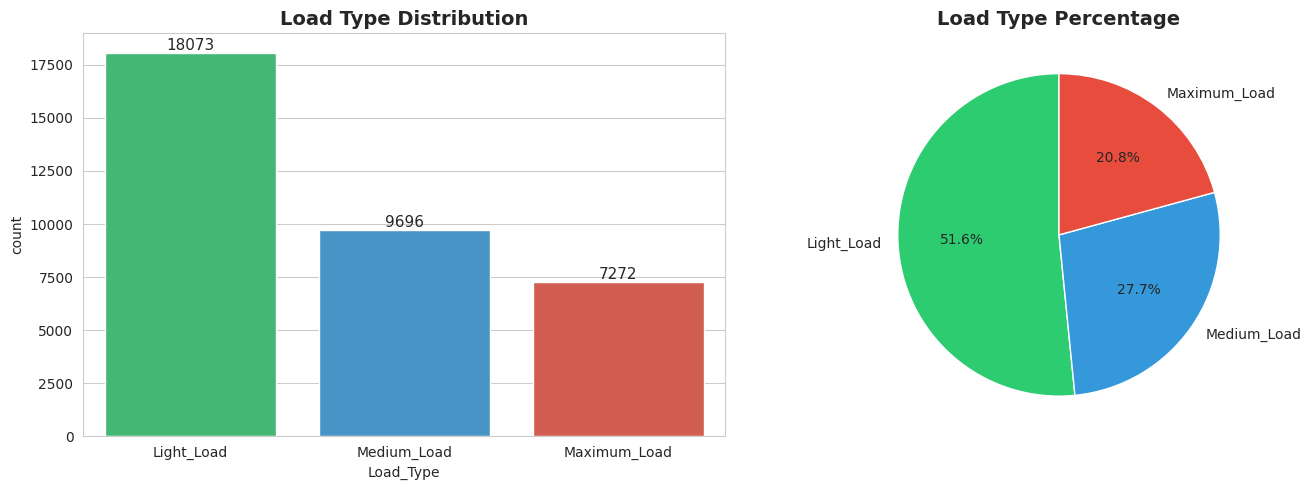

In [ ]:
# ==========================================
# CELL 8: EDA - TARGET DISTRIBUTION
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71', '#3498db', '#e74c3c']
sns.countplot(x='Load_Type', data=df, palette=colors, ax=axes[0],
              order=df['Load_Type'].value_counts().index)
axes[0].set_title('Load Type Distribution', fontsize=14, fontweight='bold')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

df['Load_Type'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1],
                                         colors=colors, startangle=90)
axes[1].set_title('Load Type Percentage', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

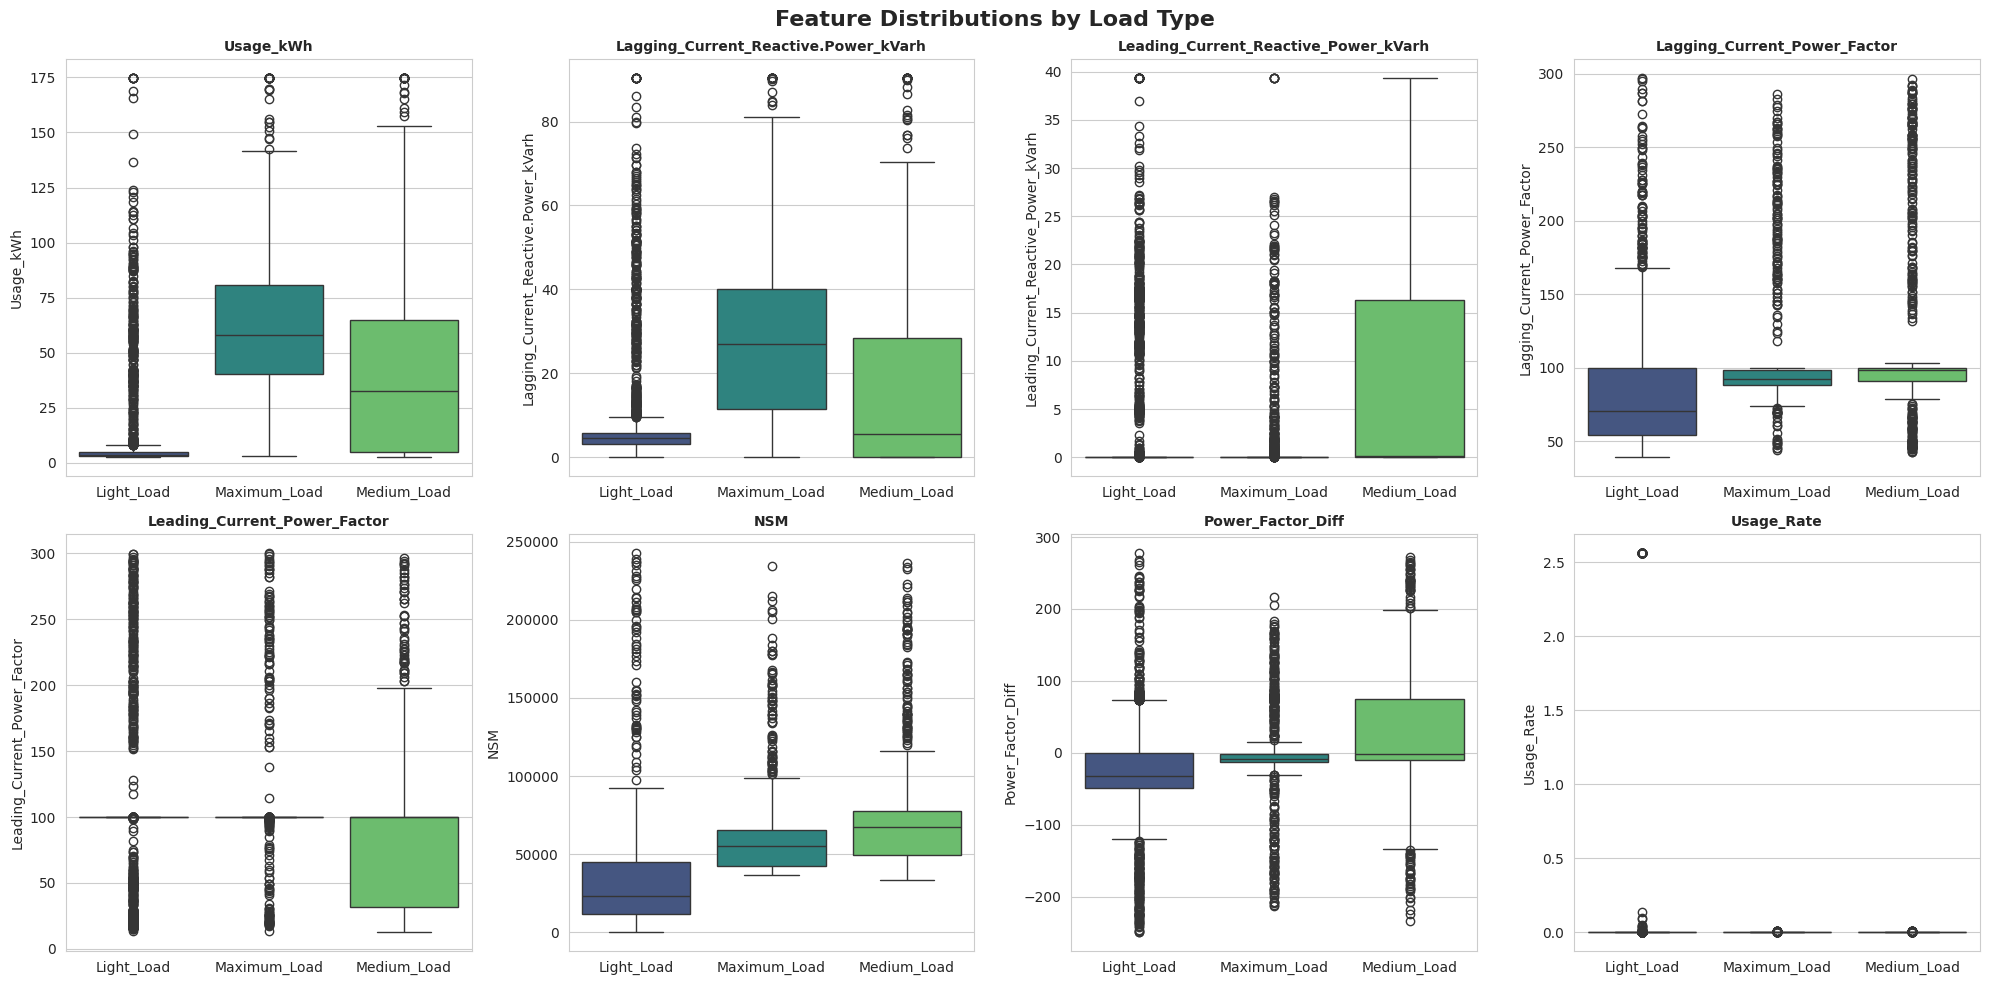

In [ ]:
# ==========================================
# CELL 9: EDA - FEATURE DISTRIBUTIONS
# ==========================================

plot_cols = ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
             'Leading_Current_Reactive_Power_kVarh',
             'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor',
             'NSM', 'Power_Factor_Diff', 'Usage_Rate']

df_sample = df.sample(n=5000, random_state=42)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    sns.boxplot(x='Load_Type', y=col, data=df_sample, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{col}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Feature Distributions by Load Type', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

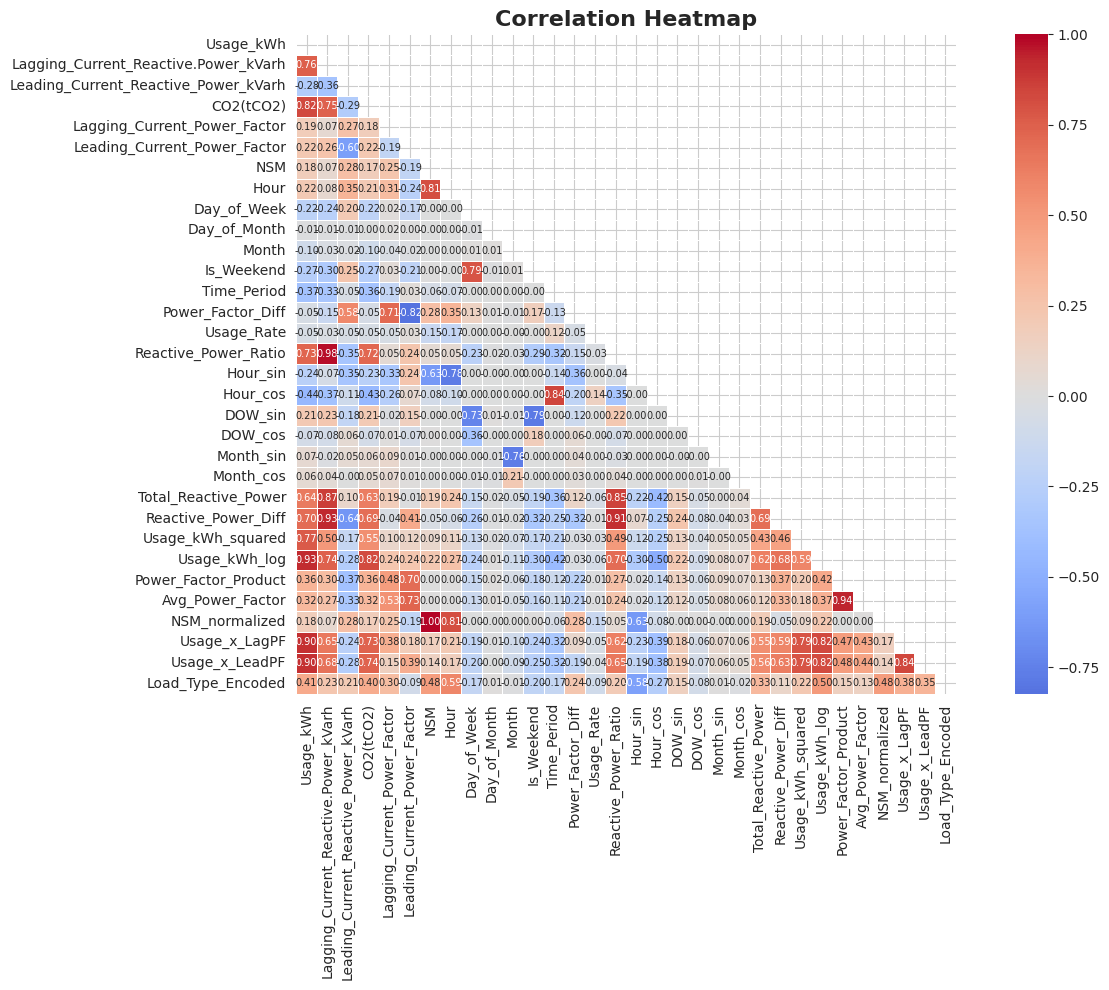


🎯 Top Correlations with Load_Type:
Hour                    0.593481
Hour_sin                0.575380
Usage_kWh_log           0.497777
NSM                     0.476566
NSM_normalized          0.476566
Usage_kWh               0.408745
CO2(tCO2)               0.398624
Usage_x_LagPF           0.378073
Usage_x_LeadPF          0.346014
Total_Reactive_Power    0.326629
Name: Load_Type_Encoded, dtype: float64


In [ ]:
# ==========================================
# CELL 10: EDA - CORRELATION HEATMAP
# ==========================================

plt.figure(figsize=(14, 10))

df_corr = df.copy()
le_temp = LabelEncoder()
df_corr['Load_Type_Encoded'] = le_temp.fit_transform(df_corr['Load_Type'])

num_cols = df_corr.select_dtypes(include=[np.number]).columns
corr_matrix = df_corr[num_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=0.5, square=True, annot_kws={'size': 7})
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n🎯 Top Correlations with Load_Type:")
target_corr = corr_matrix['Load_Type_Encoded'].drop('Load_Type_Encoded').abs().sort_values(ascending=False)
print(target_corr.head(10))

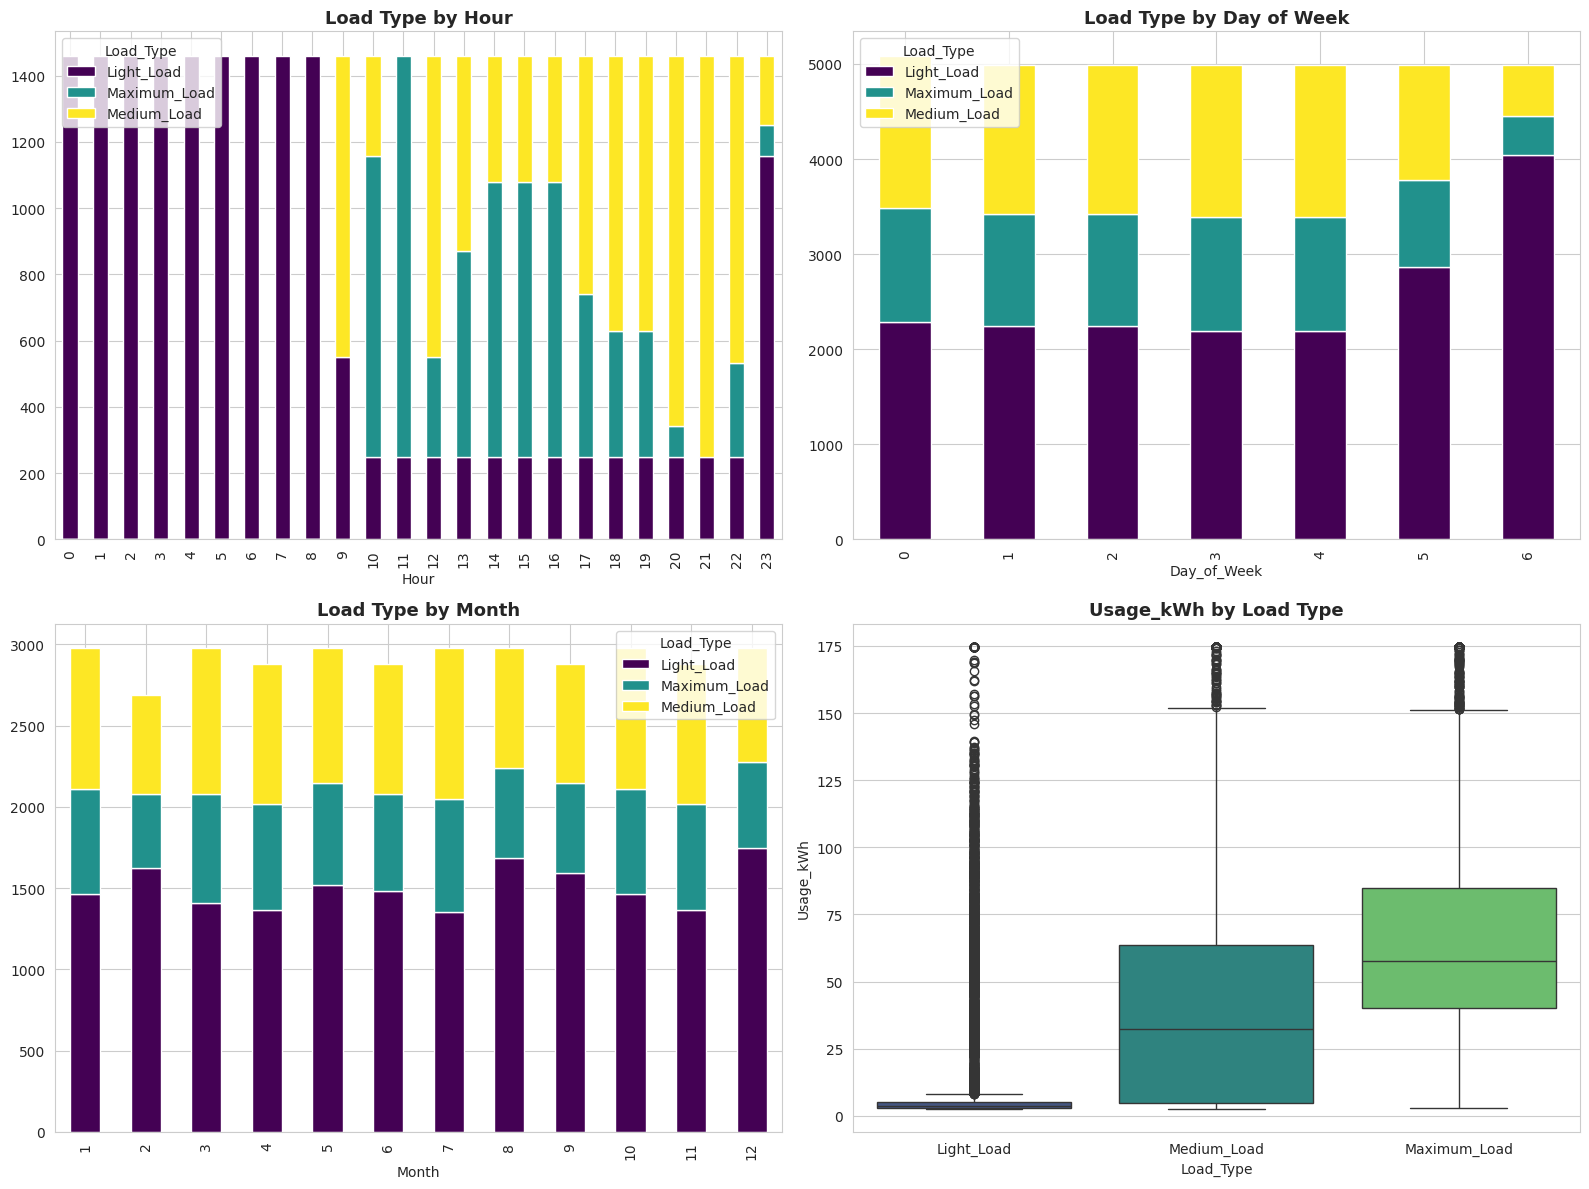

In [ ]:
# ==========================================
# CELL 11: EDA - LOAD TYPE BY TIME
# ==========================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

pd.crosstab(df['Hour'], df['Load_Type']).plot(kind='bar', stacked=True,
            ax=axes[0,0], colormap='viridis')
axes[0,0].set_title('Load Type by Hour', fontsize=13, fontweight='bold')

pd.crosstab(df['Day_of_Week'], df['Load_Type']).plot(kind='bar', stacked=True,
            ax=axes[0,1], colormap='viridis')
axes[0,1].set_title('Load Type by Day of Week', fontsize=13, fontweight='bold')

pd.crosstab(df['Month'], df['Load_Type']).plot(kind='bar', stacked=True,
            ax=axes[1,0], colormap='viridis')
axes[1,0].set_title('Load Type by Month', fontsize=13, fontweight='bold')

sns.boxplot(x='Load_Type', y='Usage_kWh', data=df, ax=axes[1,1], palette='viridis')
axes[1,1].set_title('Usage_kWh by Load Type', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# CELL 12: TRAIN-TEST SPLIT & PREPARE FEATURES
# ==========================================

print("=" * 60)
print("✂️ TRAIN-TEST SPLIT (Time-Based)")
print("=" * 60)

df = df.sort_values('Date_Time').reset_index(drop=True)

last_month = df['Date_Time'].dt.to_period('M').max()
print(f"📅 Last month: {last_month}")

train_mask = df['Date_Time'].dt.to_period('M') != last_month
test_mask = df['Date_Time'].dt.to_period('M') == last_month

train_df = df[train_mask].copy()
test_df = df[test_mask].copy()

drop_cols = ['Date_Time', 'Load_Type']

X_train = train_df.drop(columns=drop_cols)
y_train = train_df['Load_Type']
X_test = test_df.drop(columns=drop_cols)
y_test = test_df['Load_Type']

# Encode target
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Scale for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train_encoded)

print(f"\n📊 Train: {X_train.shape[0]} rows ({X_train.shape[1]} features)")
print(f"📊 Train (SMOTE): {X_train_smote.shape[0]} rows")
print(f"📊 Test: {X_test.shape[0]} rows")
print(f"🎯 Classes: {list(le.classes_)}")

✂️ TRAIN-TEST SPLIT (Time-Based)
📅 Last month: 2018-12

📊 Train: 32064 rows (31 features)
📊 Train (SMOTE): 48984 rows
📊 Test: 2977 rows
🎯 Classes: ['Light_Load', 'Maximum_Load', 'Medium_Load']


In [ ]:
# ==========================================
# CELL 13: MODEL 1 - LOGISTIC REGRESSION
# ==========================================

print("=" * 60)
print("🤖 MODEL 1: LOGISTIC REGRESSION (Baseline)")
print("=" * 60)

lr_model = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial')
lr_model.fit(X_train_scaled, y_train_encoded)
lr_pred = lr_model.predict(X_test_scaled)

print(f"\n   Accuracy:  {accuracy_score(y_test_encoded, lr_pred):.4f}")
print(f"   F1-Score:  {f1_score(y_test_encoded, lr_pred, average='weighted'):.4f}")

🤖 MODEL 1: LOGISTIC REGRESSION (Baseline)

   Accuracy:  0.6339
   F1-Score:  0.6619


In [ ]:
# ==========================================
# CELL 14: MODEL 2 - RANDOM FOREST
# ==========================================

print("=" * 60)
print("🌲 MODEL 2: RANDOM FOREST")
print("=" * 60)

rf_model = RandomForestClassifier(n_estimators=200, max_depth=20,
                                   min_samples_split=5, min_samples_leaf=2,
                                   random_state=42, n_jobs=-1, class_weight='balanced')
rf_model.fit(X_train, y_train_encoded)
rf_pred = rf_model.predict(X_test)

print(f"\n   Accuracy:  {accuracy_score(y_test_encoded, rf_pred):.4f}")
print(f"   F1-Score:  {f1_score(y_test_encoded, rf_pred, average='weighted'):.4f}")

🌲 MODEL 2: RANDOM FOREST

   Accuracy:  0.9402
   F1-Score:  0.9408


In [ ]:
# ==========================================
# CELL 15: MODELS 3-5: XGBOOST, LIGHTGBM, EXTRA TREES
# ==========================================

print("=" * 60)
print("🚀 MODELS 3-5: XGBOOST, LIGHTGBM, EXTRA TREES")
print("=" * 60)

# XGBoost
print("\n🔹 XGBoost:")
xgb_model = XGBClassifier(n_estimators=500, max_depth=10, learning_rate=0.05,
                           subsample=0.85, colsample_bytree=0.85, min_child_weight=3,
                           gamma=0.1, random_state=42, use_label_encoder=False,
                           eval_metric='mlogloss', n_jobs=-1)
xgb_model.fit(X_train_smote, y_train_smote)
xgb_pred = xgb_model.predict(X_test)
print(f"   Accuracy: {accuracy_score(y_test_encoded, xgb_pred):.4f}")
print(f"   F1-Score: {f1_score(y_test_encoded, xgb_pred, average='weighted'):.4f}")

# LightGBM
print("\n🔹 LightGBM:")
lgbm_model = LGBMClassifier(n_estimators=500, max_depth=10, learning_rate=0.05,
                              subsample=0.85, colsample_bytree=0.85, num_leaves=50,
                              random_state=42, n_jobs=-1, verbose=-1)
lgbm_model.fit(X_train_smote, y_train_smote)
lgbm_pred = lgbm_model.predict(X_test)
print(f"   Accuracy: {accuracy_score(y_test_encoded, lgbm_pred):.4f}")
print(f"   F1-Score: {f1_score(y_test_encoded, lgbm_pred, average='weighted'):.4f}")

# Extra Trees
print("\n🔹 Extra Trees:")
et_model = ExtraTreesClassifier(n_estimators=500, max_depth=20,
                                 min_samples_split=5, min_samples_leaf=2,
                                 random_state=42, n_jobs=-1, class_weight='balanced')
et_model.fit(X_train_smote, y_train_smote)
et_pred = et_model.predict(X_test)
print(f"   Accuracy: {accuracy_score(y_test_encoded, et_pred):.4f}")
print(f"   F1-Score: {f1_score(y_test_encoded, et_pred, average='weighted'):.4f}")

🚀 MODELS 3-5: XGBOOST, LIGHTGBM, EXTRA TREES

🔹 XGBoost:
   Accuracy: 0.9197
   F1-Score: 0.9205

🔹 LightGBM:
   Accuracy: 0.8878
   F1-Score: 0.8889

🔹 Extra Trees:
   Accuracy: 0.9046
   F1-Score: 0.9062


In [ ]:
# ==========================================
# CELL 16: STACKING ENSEMBLE (BEST MODEL) 🏆
# ==========================================

print("=" * 60)
print("🏆 STACKING ENSEMBLE")
print("=" * 60)
print("⏳ This may take 3-5 minutes...\n")

stacking_model = StackingClassifier(
    estimators=[
        ('xgb', XGBClassifier(n_estimators=300, max_depth=8, learning_rate=0.1,
                               subsample=0.8, colsample_bytree=0.8, random_state=42,
                               use_label_encoder=False, eval_metric='mlogloss', n_jobs=-1)),
        ('lgbm', LGBMClassifier(n_estimators=300, max_depth=8, learning_rate=0.1,
                                 subsample=0.8, colsample_bytree=0.8, random_state=42,
                                 n_jobs=-1, verbose=-1)),
        ('rf', RandomForestClassifier(n_estimators=300, max_depth=15,
                                       random_state=42, n_jobs=-1)),
        ('et', ExtraTreesClassifier(n_estimators=300, max_depth=15,
                                     random_state=42, n_jobs=-1))
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=3, n_jobs=-1, passthrough=False
)

stacking_model.fit(X_train_smote, y_train_smote)
stacking_pred = stacking_model.predict(X_test)

print(f"\n📊 STACKING RESULTS:")
print(f"   Accuracy:  {accuracy_score(y_test_encoded, stacking_pred):.4f}")
print(f"   Precision: {precision_score(y_test_encoded, stacking_pred, average='weighted'):.4f}")
print(f"   Recall:    {recall_score(y_test_encoded, stacking_pred, average='weighted'):.4f}")
print(f"   F1-Score:  {f1_score(y_test_encoded, stacking_pred, average='weighted'):.4f}")

🏆 STACKING ENSEMBLE
⏳ This may take 3-5 minutes...


📊 STACKING RESULTS:
   Accuracy:  0.9412
   Precision: 0.9443
   Recall:    0.9412
   F1-Score:  0.9416


In [ ]:
# ==========================================
# CELL 17: SOFT VOTING ENSEMBLE
# ==========================================

print("=" * 60)
print("🗳️ SOFT VOTING ENSEMBLE")
print("=" * 60)

voting_model = VotingClassifier(
    estimators=[('xgb', xgb_model), ('lgbm', lgbm_model), ('et', et_model)],
    voting='soft', n_jobs=-1
)
voting_model.fit(X_train_smote, y_train_smote)
voting_pred = voting_model.predict(X_test)

print(f"\n   Accuracy:  {accuracy_score(y_test_encoded, voting_pred):.4f}")
print(f"   F1-Score:  {f1_score(y_test_encoded, voting_pred, average='weighted'):.4f}")

🗳️ SOFT VOTING ENSEMBLE

   Accuracy:  0.9123
   F1-Score:  0.9131


📊 COMPLETE MODEL COMPARISON
              Model  Accuracy  Precision   Recall  F1-Score
  Stacking Ensemble  0.941216   0.944294 0.941216  0.941585
      Random Forest  0.940208   0.944505 0.940208  0.940837
            XGBoost  0.919718   0.930913 0.919718  0.920477
    Voting Ensemble  0.912328   0.926415 0.912328  0.913096
        Extra Trees  0.904602   0.911110 0.904602  0.906174
           LightGBM  0.887807   0.910628 0.887807  0.888858
Logistic Regression  0.633860   0.708647 0.633860  0.661870


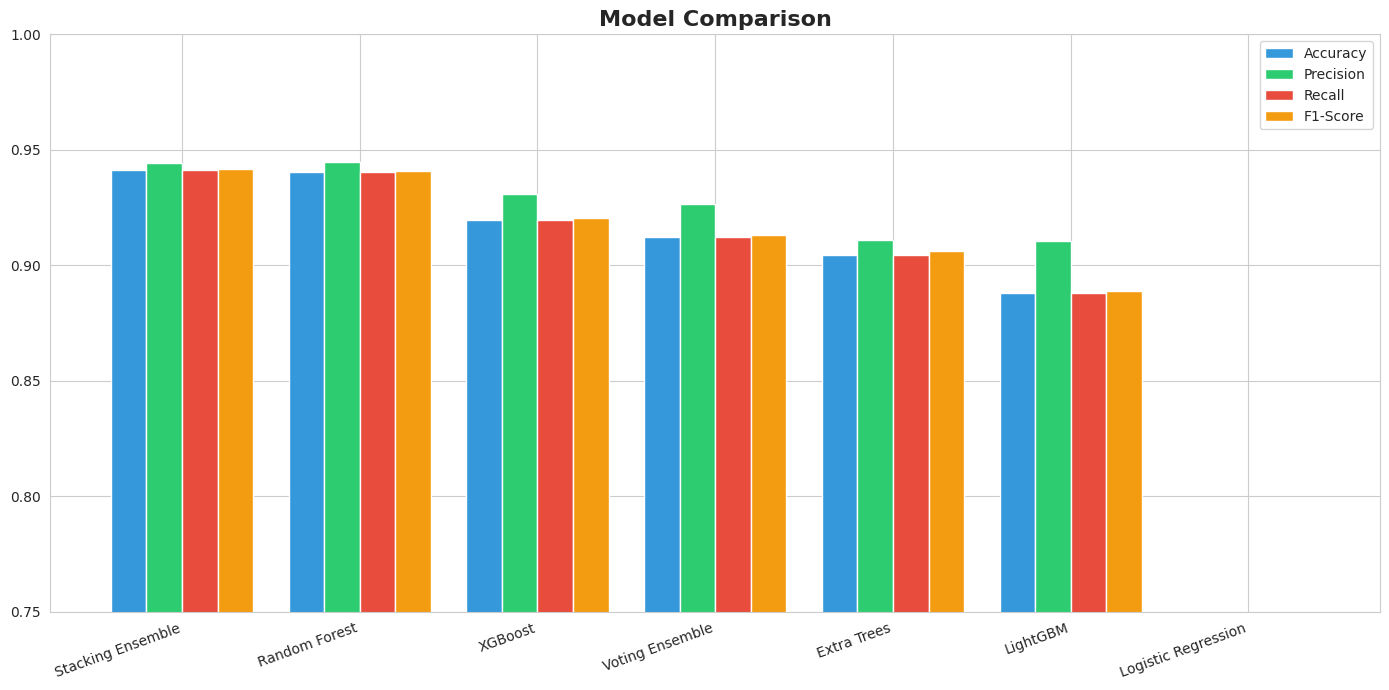


🏆 Best Model: Stacking Ensemble
   Accuracy: 0.9412 | F1: 0.9416


In [ ]:
# ==========================================
# CELL 18: COMPLETE MODEL COMPARISON
# ==========================================

print("=" * 60)
print("📊 COMPLETE MODEL COMPARISON")
print("=" * 60)

all_models = {
    'Logistic Regression': lr_pred,
    'Random Forest': rf_pred,
    'XGBoost': xgb_pred,
    'LightGBM': lgbm_pred,
    'Extra Trees': et_pred,
    'Stacking Ensemble': stacking_pred,
    'Voting Ensemble': voting_pred
}

results = []
for name, pred in all_models.items():
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test_encoded, pred),
        'Precision': precision_score(y_test_encoded, pred, average='weighted'),
        'Recall': recall_score(y_test_encoded, pred, average='weighted'),
        'F1-Score': f1_score(y_test_encoded, pred, average='weighted')
    })

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False)
print(results_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(results_df))
width = 0.2

ax.bar(x - width*1.5, results_df['Accuracy'], width, label='Accuracy', color='#3498db')
ax.bar(x - width*0.5, results_df['Precision'], width, label='Precision', color='#2ecc71')
ax.bar(x + width*0.5, results_df['Recall'], width, label='Recall', color='#e74c3c')
ax.bar(x + width*1.5, results_df['F1-Score'], width, label='F1-Score', color='#f39c12')

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=20, ha='right')
ax.set_ylim(0.75, 1.0)
ax.set_title('Model Comparison', fontsize=16, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

best = results_df.iloc[0]
print(f"\n🏆 Best Model: {best['Model']}")
print(f"   Accuracy: {best['Accuracy']:.4f} | F1: {best['F1-Score']:.4f}")

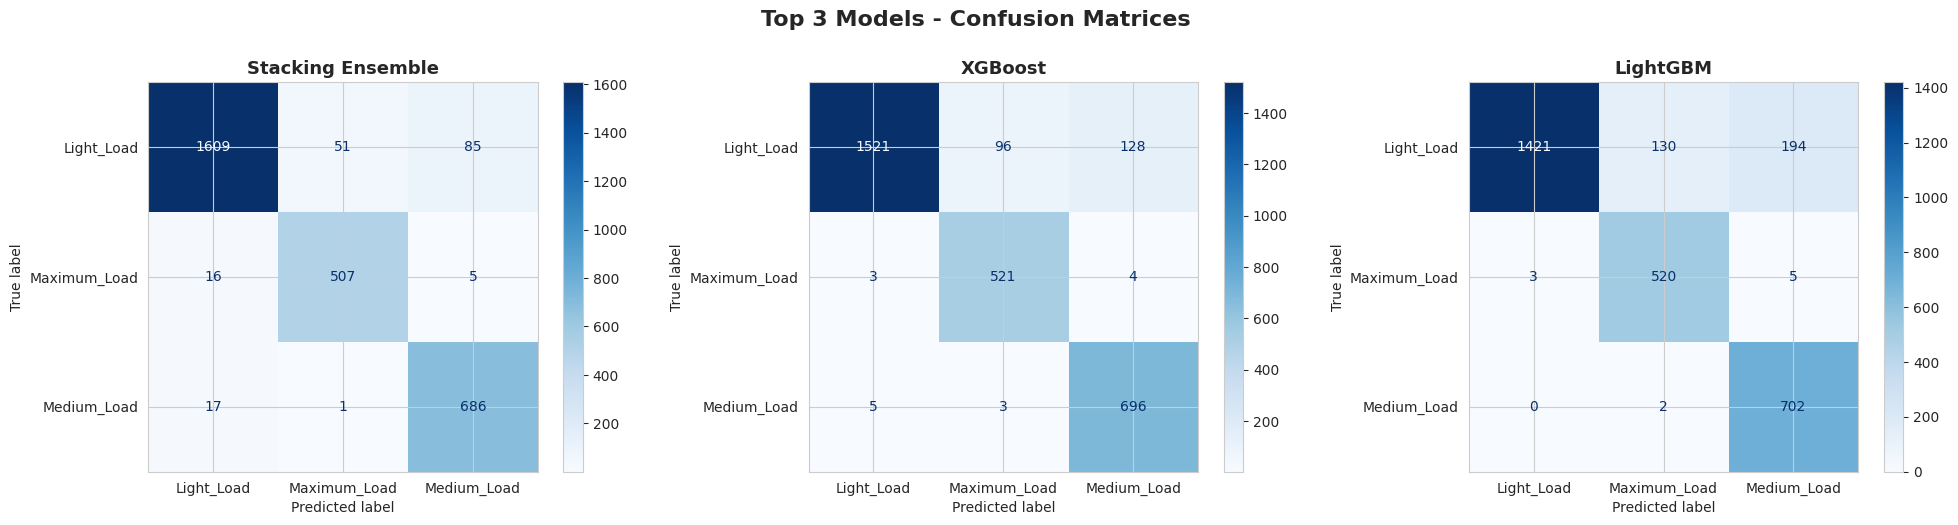

In [ ]:
# ==========================================
# CELL 19: CONFUSION MATRICES (TOP 3 MODELS)
# ==========================================

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

top_models = [
    ('Stacking Ensemble', stacking_pred),
    ('XGBoost', xgb_pred),
    ('LightGBM', lgbm_pred)
]

for idx, (name, pred) in enumerate(top_models):
    cm = confusion_matrix(y_test_encoded, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=axes[idx], cmap='Blues', values_format='d')
    axes[idx].set_title(f'{name}', fontsize=13, fontweight='bold')

plt.suptitle('Top 3 Models - Confusion Matrices', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()